# TravelTide Mastery Project

## Datenimport, Datenaufbereitung und explorative Analyse

### Projekthintergrund

TravelTide ist ein Online-Reiseunternehmen, das nach einem starken Fokus auf den Aufbau seines Reiseangebots nun die Kundenbindung verbessern möchte. Zu diesem Zweck soll ein personalisiertes Rewards-Programm entwickelt werden.

Die Head of Marketing geht davon aus, dass Kunden unterschiedliche Präferenzen für mögliche Vorteile besitzen. Eine gezielte Ansprache soll jeweils denjenigen Vorteil hervorheben, der für einen Kunden auf Basis seines bisherigen Verhaltens voraussichtlich am attraktivsten ist.

Für das Rewards-Programm werden fünf mögliche Vorteile betrachtet:

* kostenlose Hotelmahlzeit
* kostenloses Aufgabegepäck
* keine Stornierungsgebühren
* exklusive Rabatte
* eine kostenlose Hotelnacht bei gemeinsamer Flugbuchung

### Projektziel

Ziel der Analyse ist es, das bisherige Such-, Buchungs- und Reiseverhalten der TravelTide-Kunden zu untersuchen und daraus aussagekräftige Kundenmerkmale zu entwickeln.

Auf dieser Grundlage sollen:

1. Kunden mit ähnlichem Verhalten identifiziert und segmentiert werden,
2. die charakteristischen Eigenschaften der Kundengruppen beschrieben werden,
3. jedem Kunden beziehungsweise Kundensegment ein voraussichtlich bevorzugter Vorteil zugeordnet werden,
4. datenbasierte Empfehlungen für die personalisierte Kommunikation des Rewards-Programms entwickelt werden.

### Datengrundlage und Kohorte

Die Analyse basiert auf vier relationalen Tabellen mit Nutzer-, Session-, Flug- und Hotelinformationen. Die relevante Kundenkohorte wurde vorab mit SQL definiert und umfasst Nutzer mit mehr als sieben Sessions seit dem 04.01.2023.

Die extrahierten Tabellen werden in diesem Notebook eingelesen, auf ihre Datenqualität geprüft und für die Analyse vorbereitet. Anschließend werden demografische und verhaltensbezogene Merkmale entwickelt, auf Kundenebene aggregiert und explorativ untersucht.

Das Ergebnis dieses Notebooks ist eine bereinigte und interpretierbare Kundentabelle, die als Grundlage für die anschließende Kundensegmentierung und Perk-Zuweisung dient.


## 1. Datenimport und Vorbereitung

In [2]:
# Importieren der Bibliotheken
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# CSV-Dateien in Dataframes umwandeln.

users = pd.read_csv("../data/users.csv")
sessions = pd.read_csv("../data/sessions.csv")
flights = pd.read_csv("../data/flights.csv")
hotels = pd.read_csv("../data/hotels.csv")

In [4]:
# Kurze Überblick über die Größe des Datensatzes.
 
print("Users:", users.shape)
print("Sessions:", sessions.shape)
print("Flights:", flights.shape)
print("Hotels:", hotels.shape)

Users: (5998, 11)
Sessions: (49211, 13)
Flights: (13717, 13)
Hotels: (14313, 7)


In [5]:
# Erste Kontrolle durch Darstellung der obersten Zeilen.

display(users.head())
display(sessions.head())
display(flights.head())
display(hotels.head())

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date
0,23557,1958-12-08,F,True,False,usa,new york,LGA,40.777,-73.872,2021-07-22
1,94883,1972-03-16,F,True,False,usa,kansas city,MCI,39.297,-94.714,2022-02-07
2,101486,1972-12-07,F,True,True,usa,tacoma,TCM,47.138,-122.476,2022-02-17
3,101961,1980-09-14,F,True,False,usa,boston,BOS,42.364,-71.005,2022-02-17
4,106907,1978-11-17,F,True,True,usa,miami,TNT,25.862,-80.897,2022-02-24


,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,510198-48c0e1cf4fb147328bb5dbae3ca22411,510198,510198-74464b50ee984494b39460eef1e03bb2,2023-01-04 00:01:00,2023-01-04 00:04:23,False,True,NaN,0.15,True,True,28,False
1,509353-fcc7b28f87464773b8ce9a91d3b8e0df,509353,509353-f2916a48af814fd695e9617f30a86833,2023-01-04 00:52:00,2023-01-04 00:54:11,False,False,NaN,NaN,True,True,17,False
2,510571-f9265397db5e4921b1b6f569a88b2a7f,510571,510571-ddad02f4de2641c885409da85447df8d,2023-01-04 01:06:00,2023-01-04 01:07:44,True,False,0.2,NaN,False,True,14,False
3,407250-8a0a1f8f48a84e6e9d70f3582d350b43,407250,407250-9152c91fdf754cffbb345776da107919,2023-01-04 01:10:00,2023-01-04 01:12:27,False,False,NaN,NaN,True,False,20,False
4,468808-2ece675cf2f747fb8690b7c9f474c3d7,468808,NaN,2023-01-04 01:20:00,2023-01-04 01:21:08,False,False,NaN,NaN,False,False,9,False


,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,101486-1015905607d74b15954bfd4ac7029ef3,TCM,edmonton,YED,1,True,2023-06-10 10:00:00,2023-06-14 10:00:00,0,United Airlines,53.667,-113.467,189.91
1,101961-19f641633ebc442799662326f0b4dfa0,BOS,new york,LGA,1,True,2023-05-05 11:00:00,2023-05-09 11:00:00,0,Allegiant Air,40.640,-73.779,49.67
2,101961-29a8ff7c9910469c959fffa60215cf78,BOS,montreal,YHU,1,True,2023-02-08 07:00:00,2023-02-13 07:00:00,1,United Airlines,45.517,-73.417,77.02
3,101961-836fd88487d240baa4402c8e4c6f188c,BOS,seattle,BFI,1,True,2023-03-16 07:00:00,2023-03-21 07:00:00,1,Kenmore Air,47.530,-122.302,769.50
4,101961-c4c922fbc83342779565d249ee5e6bf7,BOS,charlotte,CLT,1,True,2023-06-27 11:00:00,2023-07-05 11:00:00,0,JetBlue Airways,35.214,-80.943,216.57


,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,101486-1015905607d74b15954bfd4ac7029ef3,Crowne Plaza - edmonton,3,1,2023-06-10 13:12:24.03,2023-06-14 11:00:00,253
1,101486-6759c5dd49a1457d916bb2bbf48c3115,Banyan Tree - montreal,5,2,2023-06-24 11:00:00,2023-06-29 11:00:00,144
2,101961-19f641633ebc442799662326f0b4dfa0,Conrad - new york,3,1,2023-05-05 13:22:30.72,2023-05-09 11:00:00,165
3,101961-29a8ff7c9910469c959fffa60215cf78,Rosewood - montreal,4,1,2023-02-08 09:30:00.99,2023-02-12 11:00:00,197
4,101961-836fd88487d240baa4402c8e4c6f188c,Extended Stay - seattle,4,1,2023-03-16 14:00:14.67,2023-03-21 11:00:00,132


In [ ]:
# Kontrolle, ob Datumangaben korrekt aus der CSV übernommen wurden.

print(users[["birthdate", "sign_up_date"]].dtypes)
print(sessions[["session_start", "session_end"]].dtypes)
print(flights[["departure_time", "return_time"]].dtypes)
print(hotels[["check_in_time", "check_out_time"]].dtypes)

birthdate       str
sign_up_date    str
dtype: object
session_start    str
session_end      str
dtype: object
departure_time    str
return_time       str
dtype: object
check_in_time     str
check_out_time    str
dtype: object


In [7]:
# Umwandlung der Datumsangaben in das Datetime-Format.

users["birthdate"] = pd.to_datetime(
    users["birthdate"],
    format="mixed"
)

users["sign_up_date"] = pd.to_datetime(
    users["sign_up_date"],
    format="mixed"
)

sessions["session_start"] = pd.to_datetime(
    sessions["session_start"],
    format="mixed"
)

sessions["session_end"] = pd.to_datetime(
    sessions["session_end"],
    format="mixed"
)

flights["departure_time"] = pd.to_datetime(
    flights["departure_time"],
    format="mixed"
)

flights["return_time"] = pd.to_datetime(
    flights["return_time"],
    format="mixed"
)

hotels["check_in_time"] = pd.to_datetime(
    hotels["check_in_time"],
    format="mixed"
)

hotels["check_out_time"] = pd.to_datetime(
    hotels["check_out_time"],
    format="mixed"
)

In [8]:
# Kontrolle, ob die Umwandlung korrekt erfolgt ist und keine Werte verloren gegangen sind.

print(users[["birthdate", "sign_up_date"]].dtypes)
print(sessions[["session_start", "session_end"]].dtypes)
print(flights[["departure_time", "return_time"]].dtypes)
print(hotels[["check_in_time", "check_out_time"]].dtypes)

print("\nFehlende session_start:", sessions["session_start"].isna().sum())
print("Fehlende session_end:", sessions["session_end"].isna().sum())
print("Fehlende departure_time:", flights["departure_time"].isna().sum())
print("Fehlende return_time:", flights["return_time"].isna().sum())
print("Fehlende check_in_time:", hotels["check_in_time"].isna().sum())
print("Fehlende check_out_time:", hotels["check_out_time"].isna().sum())

birthdate       datetime64[us]
sign_up_date    datetime64[us]
dtype: object
session_start    datetime64[us]
session_end      datetime64[us]
dtype: object
departure_time    datetime64[us]
return_time       datetime64[us]
dtype: object
check_in_time     datetime64[us]
check_out_time    datetime64[us]
dtype: object

Fehlende session_start: 0
Fehlende session_end: 0
Fehlende departure_time: 0
Fehlende return_time: 597
Fehlende check_in_time: 0
Fehlende check_out_time: 0


Die Tabellen `users`, `sessions`, `flights` und `hotels`, die vorab aus der relationalen TravelTide-Datenbank extrahiert wurden, wurden als separate Pandas DataFrames eingelesen. Anschließend wurden die Dimensionen und ersten Zeilen der Tabellen kontrolliert, um den erfolgreichen Import und die grundlegende Tabellenstruktur zu überprüfen.

Alle Datums- und Zeitangaben wurden in das Pandas-Datetime-Format umgewandelt. Da die Zeitstempel teilweise unterschiedliche Genauigkeiten aufweisen, wurde bei der Konvertierung eine gemischte Formaterkennung verwendet. Dadurch können die Zeitangaben im weiteren Verlauf für zeitliche Prüfungen, Differenzberechnungen und die Entwicklung neuer Merkmale genutzt werden.

## 2. Datenqualitätsprüfung

In diesem Abschnitt werden die vier Ausgangstabellen auf ihre Struktur,
fehlende Werte, Duplikate, Schlüsselbeziehungen und unplausible Werte geprüft.
Die Rohdaten werden dabei noch nicht verändert.

In [9]:
# Tabellenüberischt erstellen.

dataframes = {
    "users": users,
    "sessions": sessions,
    "flights": flights,
    "hotels": hotels
}

overview = pd.DataFrame({
    "rows": {name: len(df) for name, df in dataframes.items()},
    "columns": {name: df.shape[1] for name, df in dataframes.items()},
    "duplicate_rows": {
        name: df.duplicated().sum()
        for name, df in dataframes.items()
    },
    "missing_values": {
        name: df.isna().sum().sum()
        for name, df in dataframes.items()
    }
})

overview

,rows,columns,duplicate_rows,missing_values
users,5998,11,0,0
sessions,49211,13,0,116444
flights,13717,13,0,597
hotels,14313,7,0,0


In [10]:
# Datentypen kontrollieren

for name, df in dataframes.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


USERS
user_id                      int64
birthdate           datetime64[us]
gender                         str
married                       bool
has_children                  bool
home_country                   str
home_city                      str
home_airport                   str
home_airport_lat           float64
home_airport_lon           float64
sign_up_date        datetime64[us]
dtype: object

SESSIONS
session_id                           str
user_id                            int64
trip_id                              str
session_start             datetime64[us]
session_end               datetime64[us]
flight_discount                     bool
hotel_discount                      bool
flight_discount_amount           float64
hotel_discount_amount            float64
flight_booked                       bool
hotel_booked                        bool
page_clicks                        int64
cancellation                        bool
dtype: object

FLIGHTS
trip_id                     

In [11]:
# Fehlende Werte untersuchen.

for name, df in dataframes.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]

    print(f"\n{name.upper()}")

    if missing.empty:
        print("Keine fehlenden Werte.")
    else:
        print(missing)


USERS
Keine fehlenden Werte.

SESSIONS
trip_id                   32509
flight_discount_amount    40929
hotel_discount_amount     43006
dtype: int64

FLIGHTS
return_time    597
dtype: int64

HOTELS
Keine fehlenden Werte.


In [12]:
# Vollständig doppelte Zeilen prüfen.

for name, df in dataframes.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} vollständig doppelte Zeilen")

users: 0 vollständig doppelte Zeilen
sessions: 0 vollständig doppelte Zeilen
flights: 0 vollständig doppelte Zeilen
hotels: 0 vollständig doppelte Zeilen


In [13]:
# Primärschlüssel prüfen

key_checks = pd.DataFrame({
    "table": ["users", "sessions", "flights", "hotels"],
    "key": ["user_id", "session_id", "trip_id", "trip_id"],
    "rows": [
        len(users),
        len(sessions),
        len(flights),
        len(hotels)
    ],
    "unique_keys": [
        users["user_id"].nunique(),
        sessions["session_id"].nunique(),
        flights["trip_id"].nunique(),
        hotels["trip_id"].nunique()
    ],
    "missing_keys": [
        users["user_id"].isna().sum(),
        sessions["session_id"].isna().sum(),
        flights["trip_id"].isna().sum(),
        hotels["trip_id"].isna().sum()
    ]
})

key_checks["key_is_unique"] = (
    key_checks["rows"] == key_checks["unique_keys"]
)

key_checks

,table,key,rows,unique_keys,missing_keys,key_is_unique
0,users,user_id,5998,5998,0,True
1,sessions,session_id,49211,49211,0,True
2,flights,trip_id,13717,13717,0,True
3,hotels,trip_id,14313,14313,0,True


In [14]:
# Beziehungen zwischen den Tabellen prüfen

session_user_ids = set(sessions["user_id"])
user_ids = set(users["user_id"])

session_trip_ids = set(sessions["trip_id"].dropna())
flight_trip_ids = set(flights["trip_id"])
hotel_trip_ids = set(hotels["trip_id"])

print(
    "Session-Nutzer ohne passenden Eintrag in users:",
    len(session_user_ids - user_ids)
)

print(
    "Flüge ohne passende trip_id in sessions:",
    len(flight_trip_ids - session_trip_ids)
)

print(
    "Hotels ohne passende trip_id in sessions:",
    len(hotel_trip_ids - session_trip_ids)
)

Session-Nutzer ohne passenden Eintrag in users: 0
Flüge ohne passende trip_id in sessions: 0
Hotels ohne passende trip_id in sessions: 0


In [ ]:
# Sessions pro User prüfen (laut Kohortendefinition mindestens 7 Sessions pro User).

sessions_per_user = (
    sessions.groupby("user_id")["session_id"]
    .nunique()
)

sessions_per_user.describe()

print("Minimum:", sessions_per_user.min())
print("Maximum:", sessions_per_user.max())
print(
    "Nutzer mit höchstens 7 Sessions:",
    (sessions_per_user <= 7).sum()
)

Minimum: 8
Maximum: 12
Nutzer mit höchstens 7 Sessions: 0


## Zusammenfassung der Datenqualitätsprüfung

Die vier Ausgangstabellen `users`, `sessions`, `flights` und `hotels` wurden hinsichtlich ihrer Struktur, Vollständigkeit und Konsistenz überprüft.

* **Tabellenstruktur:** Die Anzahl der Zeilen und Spalten entspricht den erwarteten Exportergebnissen der definierten Kundenkohorte.
* **Datentypen:** IDs, kategoriale Merkmale, numerische Werte, Boolean-Variablen und Zeitangaben wurden mit passenden Datentypen eingelesen. Eine weitere Typkonvertierung ist derzeit nicht erforderlich.
* **Primärschlüssel:** Die Primärschlüssel `user_id`, `session_id` und `trip_id` sind in den jeweiligen Tabellen vollständig vorhanden und eindeutig.
* **Tabellenbeziehungen:** Alle Nutzer-IDs aus `sessions` besitzen einen passenden Eintrag in `users`. Ebenso lassen sich die Flug- und Hotelbuchungen über `trip_id` einer Session zuordnen.
* **Kohortendefinition:** Alle enthaltenen Nutzer besitzen mehr als sieben Sessions seit dem 04.01.2023 und erfüllen damit die definierte Kohortenbedingung.
* **Fehlende Werte:** Die vorhandenen Nullwerte sind fachlich plausibel. Fehlende `trip_id`-Werte kennzeichnen Sessions ohne Buchung. Fehlende Rabattbeträge treten auf, wenn kein Rabatt angeboten wurde. Fehlende Rückflugzeiten sind bei Buchungen ohne Rückflug zu erwarten.
* **Duplikate:** In keiner der vier Tabellen wurden vollständig doppelte Zeilen gefunden.
* **Schlüsselduplikate:** Die jeweiligen Primärschlüssel sind eindeutig. Mehrfach vorkommende `trip_id`-Werte in der Session-Tabelle werden separat untersucht, da mehrere Sessions mit derselben Reise zusammenhängen können.

Die grundlegende technische Datenqualität ist damit ausreichend für die weitere Analyse. Im nächsten Schritt werden fachliche Auffälligkeiten und unplausible Werte untersucht, bevor die Tabellen zu einem gemeinsamen Session-Datensatz zusammengeführt werden.

## 3. Prüfung fachlicher Auffälligkeiten

### 3.1 Hotelübernachtungen

Die Variable `nights` sollte grundsätzlich eine positive Anzahl gebuchter
Hotelübernachtungen enthalten. Werte von null oder kleiner werden daher näher
untersucht. Mithilfe von Check-in und Check-out wird geprüft, ob sich eine
plausible Aufenthaltsdauer rekonstruieren lässt.

In [16]:
# Verteilung von nights

hotels["nights"].describe()

hotels["nights"].value_counts().sort_index()

nights
-2        1
-1      104
 0     1208
 1     3132
 2     2793
 3     1956
 4     1360
 5      888
 6      669
 7      470
 8      386
 9      286
 10     233
 11     192
 12     142
 13     111
 14      78
 15      71
 16      47
 17      42
 18      29
 19      14
 20      21
 21      20
 22      11
 23       8
 24       4
 25       7
 26       3
 27       5
 28       3
 29       4
 30       2
 31       2
 32       3
 33       1
 34       3
 35       1
 40       1
 42       1
 43       1
Name: count, dtype: int64

In [ ]:
# Ungültige bzw. auffällige Werte zählen und die Verteilung anzeigen.

invalid_nights = hotels[hotels["nights"] <= 0].copy()

print("Hotelbuchungen insgesamt:", len(hotels))
print("Buchungen mit nights <= 0:", len(invalid_nights))
print(
    "Anteil auffälliger Buchungen:",
    round(len(invalid_nights) / len(hotels) * 100, 2),
    "%"
)

invalid_nights["nights"].value_counts().sort_index()

Hotelbuchungen insgesamt: 14313
Buchungen mit nights <= 0: 1313
Anteil auffälliger Buchungen: 9.17 %


nights
-2       1
-1     104
 0    1208
Name: count, dtype: int64

Die auffälligen Werte werden zunächst nicht verändert. Vor einer Bereinigung
wird geprüft, ob die Aufenthaltsdauer anhand von Check-in und Check-out
zuverlässig rekonstruiert werden kann. Dadurch soll vermieden werden, gültige
Buchungen voreilig zu entfernen oder unplausible Werte ohne ausreichende
Begründung zu ersetzen.

In [20]:
# Aufenthaltsdauer anhand der Zeitangaben berechnen und auffällige Fälle anzeigen.

hotels_check = hotels.copy()

hotels_check["stay_duration_hours"] = (
    hotels_check["check_out_time"] -
    hotels_check["check_in_time"]
).dt.total_seconds() / 3600

hotels_check["calendar_nights"] = (
    hotels_check["check_out_time"].dt.normalize() -
    hotels_check["check_in_time"].dt.normalize()
).dt.days

hotels_check.loc[
    hotels_check["nights"] <= 0,
    [
        "trip_id",
        "nights",
        "check_in_time",
        "check_out_time",
        "stay_duration_hours",
        "calendar_nights"
    ]
].head(20)

,trip_id,nights,check_in_time,check_out_time,stay_duration_hours,calendar_nights
16,149058-0562d645484d450b8908ae40825aaf46,0,2023-01-09 15:38:38.175,2023-01-10 11:00:00,19.356063,1
42,190866-39f7fdf3561541bd990b5bca9c8c18d1,0,2023-03-28 15:57:01.260,2023-03-29 11:00:00,19.049650,1
47,204943-104f0428d48b41548c8c62045d2b3af7,0,2023-03-28 15:40:43.050,2023-03-29 11:00:00,19.321375,1
58,206011-1eee865398c846379976aa1a8f76608f,0,2023-05-09 12:58:05.925,2023-05-10 11:00:00,22.031688,1
67,224996-c83b5f33943b4cbf8ec93049c6fb6166,0,2023-05-20 18:12:04.095,2023-05-21 11:00:00,16.798862,1
78,229330-d4a91967362b4441913d13f5bc8156a3,0,2023-01-29 11:40:26.985,2023-01-29 11:00:00,-0.674162,0
96,290123-7cf9274ec6d24ec99f26586bf5afac14,0,2023-01-31 11:52:12.585,2023-01-31 11:00:00,-0.870163,0
98,290123-929ee123c3bd48c2870569e824a22d8b,0,2023-07-19 13:46:35.715,2023-07-20 11:00:00,21.223413,1
110,312488-373f10484f764569a69d49d632dbbeaf,0,2023-07-16 11:49:54.570,2023-07-16 11:00:00,-0.831825,0
114,313724-5ff715143f1d48248171238f11446d82,0,2023-01-11 12:28:03.090,2023-01-12 11:00:00,22.532475,1


In [21]:
# Eingetragenen Wert mit Kalenderdifferenz vergleichen

pd.crosstab(
    hotels_check.loc[
        hotels_check["nights"] <= 0,
        "nights"
    ],
    hotels_check.loc[
        hotels_check["nights"] <= 0,
        "calendar_nights"
    ]
)

calendar_nights,-1,0,1
nights,,,
-2,1,0,0
-1,26,78,0
0,0,325,883


In [22]:
# Check-out vor Check-in prüfen

checkout_before_checkin = hotels_check[
    hotels_check["check_out_time"] <
    hotels_check["check_in_time"]
]

print(
    "Buchungen mit Check-out vor Check-in:",
    len(checkout_before_checkin)
)

Buchungen mit Check-out vor Check-in: 226


### Bereinigung der Hotelnächte

Insgesamt wurden 1.313 Hotelbuchungen mit einer Anzahl von null oder
weniger Nächten identifiziert. Dies entspricht 9,17 % der Hotelbuchungen.

Von den 1.208 Buchungen mit `nights = 0` liegen bei 883 Buchungen Check-in
und Check-out an unterschiedlichen Kalendertagen. Diese Fälle stellen
inhaltlich einen Aufenthalt mit einer Übernachtung dar. Die Nullwerte sind
vermutlich durch eine Abrundung der exakten Aufenthaltsdauer entstanden,
wenn zwischen Check-in und Check-out weniger als 24 Stunden lagen.

Da eine vorhandene Hotelbuchung mindestens eine Übernachtung umfasst,
werden alle Werte mit `nights <= 0` in der bereinigten Variable
`nights_clean` durch den Wert 1 ersetzt. Die ursprünglichen Werte werden
zur Nachvollziehbarkeit in `nights_original` erhalten.

Zusätzlich wurden 226 Buchungen identifiziert, bei denen der Check-out
zeitlich vor dem Check-in liegt. Diese Buchungen wurden nicht entfernt,
da weitere relevante Buchungsinformationen vorhanden sind. Sie wurden
mit `invalid_stay_timing` markiert. Für spätere Berechnungen der
Aufenthaltsdauer und Hotelkosten wird die bereinigte Variable
`nights_clean` verwendet.

In [ ]:
# Bereinigung der Hotelnächte in neuer Variable nights_clean, die mindestens 1 Nacht enthält.

hotels["nights_original"] = hotels["nights"]

hotels["nights_clean"] = hotels["nights"].clip(lower=1)

print(
    "Werte in nights_clean kleiner oder gleich 0 nach Bereinigung:",
    (hotels["nights_clean"] <= 0).sum()
)

Werte in nights_clean kleiner oder gleich 0 nach Bereinigung: 0


In [25]:
# Markierung von Buchungen bei denen Check-Out vor Check-In liegt

hotels["invalid_stay_timing"] = (
    hotels["check_out_time"] < hotels["check_in_time"]
)

hotels["invalid_stay_timing"].value_counts()

invalid_stay_timing
False    14087
True       226
Name: count, dtype: int64

### 3.2 Prüfung der Sessiondauer

Die Dauer einer Session kann als Merkmal für die Intensität des
Browsing-Verhaltens verwendet werden. Daher wird geprüft, ob negative,
unplausibel kurze oder außergewöhnlich lange Sessions vorhanden sind.
Auffällige Werte werden zunächst nur untersucht und noch nicht entfernt.

In [31]:
# Sessiondauer berechnen und Kontrolle einiger Beispiele.

sessions["session_duration_minutes"] = (
    sessions["session_end"] -
    sessions["session_start"]
).dt.total_seconds() / 60

sessions[
    [
        "session_id",
        "session_start",
        "session_end",
        "session_duration_minutes",
        "page_clicks"
    ]
].head()


,session_id,session_start,session_end,session_duration_minutes,page_clicks
0,510198-48c0e1cf4fb147328bb5dbae3ca22411,2023-01-04 00:01:00,2023-01-04 00:04:23,3.383333,28
1,509353-fcc7b28f87464773b8ce9a91d3b8e0df,2023-01-04 00:52:00,2023-01-04 00:54:11,2.183333,17
2,510571-f9265397db5e4921b1b6f569a88b2a7f,2023-01-04 01:06:00,2023-01-04 01:07:44,1.733333,14
3,407250-8a0a1f8f48a84e6e9d70f3582d350b43,2023-01-04 01:10:00,2023-01-04 01:12:27,2.450000,20
4,468808-2ece675cf2f747fb8690b7c9f474c3d7,2023-01-04 01:20:00,2023-01-04 01:21:08,1.133333,9


In [28]:
# Verteilung untersuchen

sessions["session_duration_minutes"].describe()

count    49211.000000
mean         3.120872
std         11.004169
min          0.100000
25%          0.750000
50%          1.600000
75%          2.700000
max        120.000000
Name: session_duration_minutes, dtype: float64

In [ ]:
# Verteilung in Quantilen untersuchen

sessions["session_duration_minutes"].quantile(
    [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1]
)

0.00      0.100000
0.01      0.233333
0.05      0.350000
0.25      0.750000
0.50      1.600000
0.75      2.700000
0.95      5.483333
0.99     45.956023
1.00    120.000000
Name: session_duration_minutes, dtype: float64

In [32]:
# Negative und null Minuten prüfen

print(
    "Negative Sessiondauern:",
    (sessions["session_duration_minutes"] < 0).sum()
)

print(
    "Sessions mit Dauer 0:",
    (sessions["session_duration_minutes"] == 0).sum()
)

Negative Sessiondauern: 0
Sessions mit Dauer 0: 0


In [34]:
# Verhältnis zwischen Klicks und Dauer prüfen

sessions["clicks_per_minute"] = np.where(
    sessions["session_duration_minutes"] > 0,
    sessions["page_clicks"] /
    sessions["session_duration_minutes"],
    np.nan
)

sessions[
    [
        "session_duration_minutes",
        "page_clicks",
        "clicks_per_minute"
    ]
].describe()

,session_duration_minutes,page_clicks,clicks_per_minute
count,49211.000000,49211.000000,49211.000000
mean,3.120872,17.588791,7.945860
std,11.004169,21.495987,0.782123
min,0.100000,1.000000,0.931622
25%,0.750000,6.000000,7.894737
50%,1.600000,13.000000,8.041237
75%,2.700000,22.000000,8.171206
max,120.000000,566.000000,10.000000


In [36]:
# Längeste Sessions ansehen.

sessions.nlargest(
    20,
    "session_duration_minutes"
)[
    [
        "session_id",
        "user_id",
        "session_start",
        "session_end",
        "session_duration_minutes",
        "page_clicks",
        "flight_booked",
        "hotel_booked",
        "cancellation"
    ]
]

,session_id,user_id,session_start,session_end,session_duration_minutes,page_clicks,flight_booked,hotel_booked,cancellation
104,498500-4f54c05abc824775937b6a61b322f400,498500,2023-01-04 13:50:00,2023-01-04 15:50:00,120.0,200,True,True,True
504,174997-d37e4081489646fc891296f5e21b96f1,174997,2023-01-05 20:17:50,2023-01-05 22:17:50,120.0,155,True,True,True
858,513787-65a5164555c747b38261a48b385a8944,513787,2023-01-06 21:08:49,2023-01-06 23:08:49,120.0,129,True,True,True
940,510694-4e89f24e711441b087491397f7b6e938,510694,2023-01-07 07:45:24,2023-01-07 09:45:24,120.0,200,True,True,True
1376,468409-78c0b06b3dca4321b8b5deffa42dad86,468409,2023-01-08 17:18:05,2023-01-08 19:18:05,120.0,200,True,True,True
1961,514167-0d8d6b21e335428988fa3adb2105de67,514167,2023-01-10 11:34:21,2023-01-10 13:34:21,120.0,200,True,True,True
1985,389434-005264cac69245a09c9826f0677ef1d9,389434,2023-01-10 13:29:54,2023-01-10 15:29:54,120.0,200,True,True,True
2836,357737-5fbbcafc49394204b7ed811212bb7cb4,357737,2023-01-12 19:30:41,2023-01-12 21:30:41,120.0,200,True,True,True
3913,508111-770195c941ad4c57808fe5bd652af8fa,508111,2023-01-15 19:58:58,2023-01-15 21:58:58,120.0,200,True,True,True
4610,525844-8c6e43f8c7cd4789af29ad23edf5299a,525844,2023-01-17 17:59:31,2023-01-17 19:59:31,120.0,200,True,True,True


In [37]:
# Sessions mit den meisten Klicks ansehen.

sessions.nlargest(
    20,
    "page_clicks"
)[
    [
        "session_id",
        "user_id",
        "session_duration_minutes",
        "page_clicks",
        "clicks_per_minute",
        "flight_booked",
        "hotel_booked"
    ]
]

,session_id,user_id,session_duration_minutes,page_clicks,clicks_per_minute,flight_booked,hotel_booked
40971,590420-814ccf31a57445a889176d909b2c2057,590420,70.000000,566,8.085714,True,True
14226,478760-fe8c0bca3345472ba2fe168745c04388,478760,34.033333,279,8.197845,False,False
9665,514300-a1cc57558ca74fc291b46a6f7aa59f84,514300,33.900000,274,8.082596,True,False
7660,499780-0e658ccf562d4362a89b5fe311e7d16a,499780,32.216667,262,8.132437,False,False
17353,602734-dd027e8dbab2430a803fed1caed3e510,602734,32.316667,262,8.107272,True,True
15724,567651-98c3c9de6a6645938f437412aac2dd37,567651,32.216667,261,8.101397,False,False
29567,558270-f48505641cbd44d39c70f817e0b5ddb9,558270,30.066667,243,8.082040,False,False
40456,527944-1ea3d8a5b46a4b4ea74780c74fa63109,527944,29.433333,237,8.052095,False,False
30200,619079-70721bc014c64bca8bc33ceeb92dd205,619079,27.966667,228,8.152563,True,True
28007,524448-bc3f0c5a5db54223afba86517101d028,524448,27.383333,222,8.107121,True,True


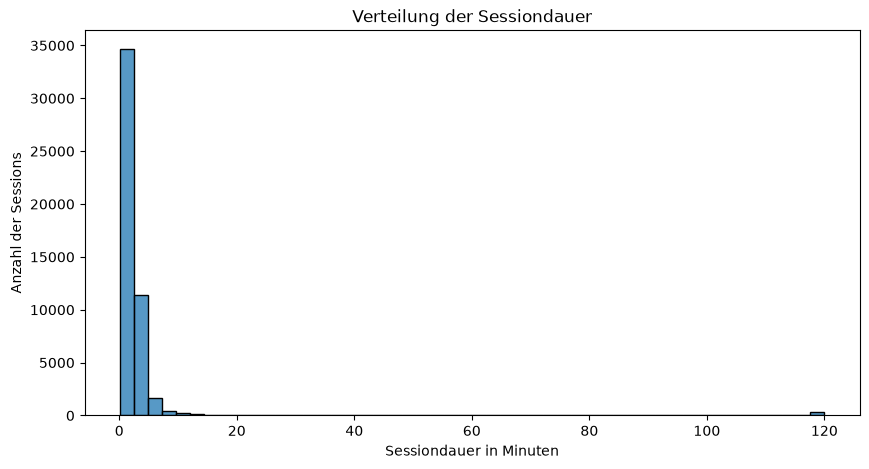

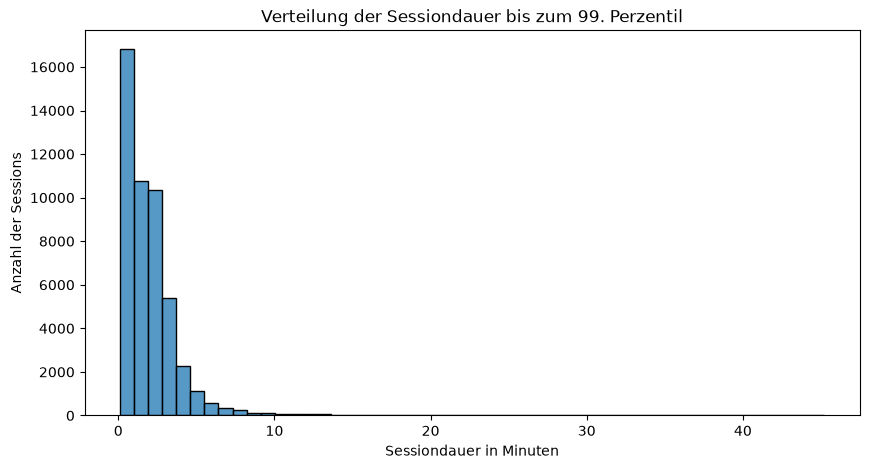

In [41]:
# Verteilung der Sesssiondauer visualisieren

plt.figure(figsize=(10, 5))

sns.histplot(
    data=sessions,
    x="session_duration_minutes",
    bins=50
)

plt.title("Verteilung der Sessiondauer")
plt.xlabel("Sessiondauer in Minuten")
plt.ylabel("Anzahl der Sessions")
plt.show()

session_duration_p99 = sessions[
    "session_duration_minutes"
].quantile(0.99)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=sessions[
        sessions["session_duration_minutes"] <= session_duration_p99
    ],
    x="session_duration_minutes",
    bins=50
)

plt.title("Verteilung der Sessiondauer bis zum 99. Perzentil")
plt.xlabel("Sessiondauer in Minuten")
plt.ylabel("Anzahl der Sessions")
plt.show()

In [43]:
# Prüfung der Sessions mit nur einem Klick (laut Datensatzbeschreibung sollte min. 2 Klicks pro Session vorhanden sein).


sessions_with_few_clicks = sessions[
    sessions["page_clicks"] < 2
]

print(
    "Sessions mit weniger als 2 Klicks:",
    len(sessions_with_few_clicks)
)

sessions_with_few_clicks[
    [
        "session_id",
        "user_id",
        "session_start",
        "session_end",
        "session_duration_minutes",
        "page_clicks",
        "flight_booked",
        "hotel_booked",
        "cancellation"
    ]
]

Sessions mit weniger als 2 Klicks: 424


,session_id,user_id,session_start,session_end,session_duration_minutes,page_clicks,flight_booked,hotel_booked,cancellation
15,510618-15ad88eb6d794856b6f13c5800feec32,510618,2023-01-04 03:28:00,2023-01-04 03:28:09,0.150000,1,False,False,False
271,511424-28b5254a75ba48ac8791002c5e17d5ad,511424,2023-01-05 03:23:00,2023-01-05 03:23:09,0.150000,1,False,False,False
509,512419-0363ee819e8d4ca3a3ddef2829b4cd4c,512419,2023-01-05 20:26:00,2023-01-05 20:26:09,0.150000,1,False,False,False
765,512943-0fc98b476a714f968c5c10e09b1567e0,512943,2023-01-06 18:11:00,2023-01-06 18:11:08,0.133333,1,False,False,False
845,512706-6555e31594b6487c94dbfb728e5f17e0,512706,2023-01-06 20:38:00,2023-01-06 20:38:07,0.116667,1,False,False,False
...,...,...,...,...,...,...,...,...,...
48420,445351-91adc0f145d14a73b9d6538e72acc34a,445351,2023-07-15 21:39:00,2023-07-15 21:39:08,0.133333,1,False,False,False
48811,639168-ab23293b67ac4fd0a7089508182ca9bd,639168,2023-07-18 18:10:00,2023-07-18 18:10:07,0.116667,1,False,False,False
48858,612226-e6ab7850d348435ab164a307ec5d560f,612226,2023-07-18 22:37:00,2023-07-18 22:37:08,0.133333,1,False,False,False
48998,656626-acf75d1599454026a4c96a70a1af0735,656626,2023-07-19 21:33:00,2023-07-19 21:33:08,0.133333,1,False,False,False


### Ergebnis der Prüfung der Sessiondauer

Die Sessiondauer weist keine negativen Werte oder Werte von null auf. Die
typische Session ist kurz: Der Median liegt bei 1,6 Minuten und 95 % der
Sessions dauern höchstens etwa 5,5 Minuten. Die Verteilung ist deutlich
rechtsschief, da eine kleine Gruppe längerer Sessions bis zu 120 Minuten
umfasst.

Die längeren Sessions weisen gleichzeitig eine entsprechend hohe Anzahl an
Seitenklicks auf. Die Klickrate liegt über den gesamten Datensatz hinweg
relativ stabil bei ungefähr acht Klicks pro Minute. Die langen Sessions
werden daher als plausibles intensives Browsing-Verhalten interpretiert und
nicht entfernt.

Für die spätere Aggregation auf Kundenebene werden sowohl die
durchschnittliche als auch die mediane Sessiondauer betrachtet. Dadurch kann
zwischen durchschnittlicher Browsing-Intensität und dem typischen Verhalten
eines Kunden unterschieden werden.

In der Variable `page_clicks` wurde mindestens eine Session mit weniger als
zwei Klicks festgestellt. Da die Datensatzbeschreibung mindestens zwei
Klicks pro Session voraussetzt, werden diese Fälle separat geprüft.

### Sessions mit weniger als zwei Klicks

In [45]:
# Markierung der Sessions mit weniger als 2 Klicks in einer neuen Spalte low_click_session.

sessions["low_click_session"] = (
    sessions["page_clicks"] < 2
)

sessions["low_click_session"].value_counts()

# Prüfung wie viele User betroffen sind, die mindestens eine Session mit weniger als 2 Klicks hatten.

print(
    "Betroffene Nutzer:",
    sessions.loc[
        sessions["low_click_session"],
        "user_id"
    ].nunique()
)

Betroffene Nutzer: 417


Obwohl die Datensatzbeschreibung ausschließlich Sessions mit mindestens
zwei Klicks vorsieht, wurden 424 Sessions mit nur einem registrierten Klick
identifiziert. Dies entspricht rund 0,86 % aller Sessions.

Die betroffenen Sessions weisen eine positive Sessiondauer auf und sind
damit nicht grundsätzlich technisch unplausibel. Sie können kurze Besuche
mit geringer Nutzerinteraktion darstellen. Da die Kundenkohorte anhand der
vorhandenen Sessionanzahl definiert wurde, würde ein nachträglicher
Ausschluss außerdem eine erneute Prüfung und gegebenenfalls Anpassung der
Kohorte erfordern.

Die Sessions werden deshalb nicht entfernt. Stattdessen werden sie mit der
binären Variable `low_click_session` gekennzeichnet. Bei der späteren
Feature-Auswahl wird geprüft, ob der Anteil solcher Sessions ein
aussagekräftiges Merkmal des Kundenverhaltens darstellt.

### 3.3 Konsistenz der Buchungsinformationen

Die Session-Tabelle enthält Buchungsflags und eine optionale `trip_id`.
Die Tabellen `flights` und `hotels` enthalten die Details der jeweiligen
Buchungen. Vor der Zusammenführung wird geprüft, ob Buchungsflags,
Reise-IDs und Detailtabellen logisch miteinander übereinstimmen.

Abweichungen werden zunächst untersucht, da dieselbe Reise-ID auch in
späteren Sessions, beispielsweise bei einer Stornierung, vorkommen kann.

In [70]:
# Kennzeichnen, ob ein Flug oder Hotel im Detaildatensatz vorhanden ist.

flight_trip_ids = set(flights["trip_id"])
hotel_trip_ids = set(hotels["trip_id"])

sessions["has_flight_record"] = (
    sessions["trip_id"].isin(flight_trip_ids)
)

sessions["has_hotel_record"] = (
    sessions["trip_id"].isin(hotel_trip_ids)
)

In [71]:
# Buchungsflags mit Detailtabellen vergleichen.

pd.crosstab(
    sessions["flight_booked"],
    sessions["has_flight_record"],
    margins=True
)

pd.crosstab(
    sessions["hotel_booked"],
    sessions["has_hotel_record"],
    margins=True
)

has_hotel_record,False,True,All
hotel_booked,,,
False,34292,0,34292
True,193,14726,14919
All,34485,14726,49211


In [72]:
# Problematische Fälle ansehen.

flight_booking_without_record = sessions[
    sessions["flight_booked"] &
    ~sessions["has_flight_record"]
]

hotel_booking_without_record = sessions[
    sessions["hotel_booked"] &
    ~sessions["has_hotel_record"]
]

print(
    "Flugbuchungen ohne Flugdatensatz:",
    len(flight_booking_without_record)
)

print(
    "Hotelbuchungen ohne Hoteldatensatz:",
    len(hotel_booking_without_record)
)

Flugbuchungen ohne Flugdatensatz: 50
Hotelbuchungen ohne Hoteldatensatz: 193


In [73]:
# Prüfen, ob die Flugbuchungen ohne Datensatz eine Stornierung sein könnte.

flight_booking_without_record[
    "cancellation"
].value_counts()

cancellation
True    50
Name: count, dtype: int64

In [74]:
# Prüfen, ob die Hotelbuchungen ohne Datensatz eine Stornierung sein könnte.

hotel_booking_without_record[
    "cancellation"
].value_counts()

cancellation
True    193
Name: count, dtype: int64

In [ ]:
# Buchung ohne trip_id prüfen.
 
print(
    "Flugbuchungen ohne trip_id:",
    (
        sessions["flight_booked"] &
        sessions["trip_id"].isna()
    ).sum()
)

print(
    "Hotelbuchungen ohne trip_id:",
    (
        sessions["hotel_booked"] &
        sessions["trip_id"].isna()
    ).sum()
)

Flugbuchungen ohne trip_id: 0
Hotelbuchungen ohne trip_id: 0


In [75]:
# Stornierungen ohne trip_id prüfen.

print(
    "Stornierungen insgesamt:",
    sessions["cancellation"].sum()
)

print(
    "Stornierungen ohne trip_id:",
    (
        sessions["cancellation"] &
        sessions["trip_id"].isna()
    ).sum()
)

pd.crosstab(
    sessions["cancellation"],
    [
        sessions["has_flight_record"],
        sessions["has_hotel_record"]
    ],
    margins=True
)

Stornierungen insgesamt: 610
Stornierungen ohne trip_id: 0


has_flight_record  False        True           All
has_hotel_record   False  True False   True       
cancellation                                      
False              32509  2382  1783  11927  48601
True                   0    50   193    367    610
All                32509  2432  1976  12294  49211

In [53]:
# Datensatz vorhanden, aber Buchungsflag False

flight_record_without_booking_flag = sessions[
    ~sessions["flight_booked"] &
    sessions["has_flight_record"]
]

hotel_record_without_booking_flag = sessions[
    ~sessions["hotel_booked"] &
    sessions["has_hotel_record"]
]

print(
    "Flugdatensatz vorhanden, flight_booked aber False:",
    len(flight_record_without_booking_flag)
)

print(
    "Hoteldatensatz vorhanden, hotel_booked aber False:",
    len(hotel_record_without_booking_flag)
)

print(
    "Davon Flug-Stornierungssessions:",
    flight_record_without_booking_flag["cancellation"].sum()
)

print(
    "Davon Hotel-Stornierungssessions:",
    hotel_record_without_booking_flag["cancellation"].sum()
)

Flugdatensatz vorhanden, flight_booked aber False: 0
Hoteldatensatz vorhanden, hotel_booked aber False: 0
Davon Flug-Stornierungssessions: 0
Davon Hotel-Stornierungssessions: 0


In [ ]:
# Mehrfach verwendete trip_ids prüfen

trip_session_counts = (
    sessions.dropna(subset=["trip_id"])
    .groupby("trip_id")["session_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(
    "Reisen mit mehr als einer Session:",
    (trip_session_counts > 1).sum()
)

print(
    "Maximale Anzahl Sessions pro Reise:",
    trip_session_counts.max()
)

trip_session_counts.value_counts().sort_index()

Reisen mit mehr als einer Session: 603
Maximale Anzahl Sessions pro Reise: 2


session_id
1    15496
2      603
Name: count, dtype: int64

In [ ]:
# Prüfung, ob die zweite Session eine Stornierung ist.

repeated_trip_ids = trip_session_counts[
    trip_session_counts > 1
].index

repeated_trip_sessions = sessions[
    sessions["trip_id"].isin(repeated_trip_ids)
]

pd.crosstab(
    repeated_trip_sessions["trip_id"],
    repeated_trip_sessions["cancellation"]
).head(20)

cancellation,False,True
trip_id,,
106907-718c9cf6c29245fa9b2b31893833ac2c,1,1
171470-dbac73113fbe4a5aa537f55f976f63e7,1,1
204943-5efc41a2816e4e9384c6356f547860e2,1,1
204997-7de2de0693be4c16963e23f7f90bd324,1,1
216796-e239539111354f4e9d333877dde83ae0,1,1
220725-ede7d3bf960044e4b519a30dcb3f9294,1,1
229009-63a0845c98ca46d3a0353b136e3174cc,1,1
229108-b5c1cf29f6cb4c0b9d0970ee489b68be,1,1
258451-69d3c630b048471891772154fd235670,1,1


In [ ]:
# Prüfung wie viele Stornierung bei Sessions mit mehrfach verwendeter trip_ids auftreten.

repeated_trip_summary = (
    repeated_trip_sessions
    .groupby("trip_id")
    .agg(
        number_of_sessions=("session_id", "nunique"),
        number_of_cancellations=("cancellation", "sum")
    )
)

repeated_trip_summary[
    "number_of_cancellations"
].value_counts().sort_index()

number_of_cancellations
1    603
Name: count, dtype: int64

In [59]:
# Sessions mit mehrfach verwendeter trip_ids anzeigen

repeated_trip_ids = trip_session_counts[
    trip_session_counts > 1
].index

sessions[
    sessions["trip_id"].isin(repeated_trip_ids)
][
    [
        "trip_id",
        "session_id",
        "user_id",
        "session_start",
        "flight_booked",
        "hotel_booked",
        "cancellation",
        "has_flight_record",
        "has_hotel_record"
    ]
].sort_values(
    ["trip_id", "session_start"]
).head(30)

,trip_id,session_id,user_id,session_start,flight_booked,hotel_booked,cancellation,has_flight_record,has_hotel_record
42792,106907-718c9cf6c29245fa9b2b31893833ac2c,106907-92db03fd9d5d44d0944650f51676b869,106907,2023-06-06 09:41:00,True,True,False,True,True
49203,106907-718c9cf6c29245fa9b2b31893833ac2c,106907-e81b73b444b64b92ab236dabfd06b930,106907,2023-07-27 09:43:48,True,True,True,True,True
45049,171470-dbac73113fbe4a5aa537f55f976f63e7,171470-170664044d184084ad71eab0b00b79f7,171470,2023-06-22 02:45:00,True,False,False,True,False
47617,171470-dbac73113fbe4a5aa537f55f976f63e7,171470-f7cf9854de5f4faa8f467b7ec2b1c03a,171470,2023-07-10 02:46:09,True,True,True,True,False
44239,204943-5efc41a2816e4e9384c6356f547860e2,204943-0de6d5e95b9b4ef9ad464cc69b832d7e,204943,2023-06-16 12:49:00,True,True,False,True,True
49207,204943-5efc41a2816e4e9384c6356f547860e2,204943-2e94ce7e5ca54986b68f78d4898483bc,204943,2023-07-28 12:51:08,True,True,True,True,True
38723,204997-7de2de0693be4c16963e23f7f90bd324,204997-da25052a2dde427b91d7cf1d19d340c5,204997,2023-05-09 20:10:00,True,True,False,True,True
38730,204997-7de2de0693be4c16963e23f7f90bd324,204997-c91e55e8e3804784ad998e48c48f10c7,204997,2023-05-09 20:25:06,True,True,True,True,True
24897,216796-e239539111354f4e9d333877dde83ae0,216796-b3e0d3b342e3468fad266d656fe8d950,216796,2023-03-10 03:36:00,True,True,False,True,True
26032,216796-e239539111354f4e9d333877dde83ae0,216796-8146dad4126546e89fb342dcc8f9b621,216796,2023-03-13 03:38:26,True,True,True,True,True


In [77]:
# Kennzeichnen der Trips, die storniert wurden.

cancelled_trip_ids = set(
    sessions.loc[
        sessions["cancellation"],
        "trip_id"
    ].dropna()
)

sessions["trip_cancelled"] = (
    sessions["trip_id"].isin(cancelled_trip_ids)
)

### Ergebnis der Konsistenzprüfung der Buchungsdaten

Alle Flug- und Hotelbuchungen besitzen eine `trip_id`. Ebenso kann jede
Stornierung einer Reise-ID zugeordnet werden.

Es wurden 50 Flugbuchungen ohne zugehörigen Flugdatensatz und 193
Hotelbuchungen ohne zugehörigen Hoteldatensatz identifiziert. Diese
Abweichungen stehen systematisch mit Stornierungen in Verbindung: Bei 50
Stornierungen ist nur ein Hoteldatensatz vorhanden, während bei 193
Stornierungen nur ein Flugdatensatz vorliegt. Weitere 367 Stornierungen
besitzen sowohl Flug- als auch Hoteldaten. Keine Stornierung ist ohne beide
Detaildatensätze.

Darüber hinaus kommen 603 Reise-IDs in jeweils zwei Sessions vor. Dies
deutet darauf hin, dass eine Reise zunächst gebucht und in einer späteren
Session storniert wurde. Die mehrfach vorkommenden Reise-IDs stellen daher
keine vollständigen Duplikate dar.

Die betreffenden Zeilen werden nicht entfernt. Stornierte Reisen werden
stattdessen mithilfe der Variable `trip_cancelled` gekennzeichnet. Bei der
späteren Aggregation werden Session- und Reiseinformationen getrennt
behandelt, um Buchungswerte nicht durch mehrfach vorkommende Reise-IDs
doppelt zu zählen.

### 3.4 Plausibilität der Flug- und Hotelbuchungen

Die numerischen Werte und Zeitangaben der Flug- und Hotelbuchungen werden
auf fachlich unplausible Werte überprüft. Dazu gehören insbesondere
negative oder fehlende Preise, Sitzplätze, Zimmer und Gepäckstücke sowie
unlogische Abflug-, Rückflug-, Check-in- und Check-out-Zeitpunkte.

Die Prüfung dient dazu, mögliche Fehler vor der Zusammenführung der
Tabellen zu identifizieren.

In [ ]:
# Numerische Flugwerte prüfen.

flight_numeric_columns = [
    "seats",
    "checked_bags",
    "base_fare_usd"
]

flights[flight_numeric_columns].describe()

,seats,checked_bags,base_fare_usd
count,13717.000000,13717.000000,13717.000000
mean,1.200044,0.582562,490.700007
std,0.555145,0.657846,701.362388
min,1.000000,0.000000,2.410000
25%,1.000000,0.000000,198.530000
50%,1.000000,1.000000,378.050000
75%,1.000000,1.000000,591.080000
max,8.000000,8.000000,21548.040000


In [ ]:
# Konkrete Auffälligkeiten bei den Flugbuchungen zählen.
 
print(
    "Flüge mit höchstens 0 Sitzplätzen:",
    (flights["seats"] <= 0).sum()
)

print(
    "Flüge mit negativer Gepäckanzahl:",
    (flights["checked_bags"] < 0).sum()
)

print(
    "Flüge mit Preis <= 0:",
    (flights["base_fare_usd"] <= 0).sum()
)

Flüge mit höchstens 0 Sitzplätzen: 0
Flüge mit negativer Gepäckanzahl: 0
Flüge mit Preis <= 0: 0


In [ ]:
# Rückfluginformationen prüfen

pd.crosstab(
    flights["return_flight_booked"],
    flights["return_time"].isna(),
    margins=True
)

return_time,False,True,All
return_flight_booked,,,
False,0,597,597
True,13120,0,13120
All,13120,597,13717


In [ ]:
# Konkrete Auffälligkeiten bei den Rückflügen zählen.
 
print(
    "Gebuchter Rückflug ohne Rückflugzeit:",
    (
        flights["return_flight_booked"] &
        flights["return_time"].isna()
    ).sum()
)

print(
    "Rückflugzeit vorhanden, obwohl kein Rückflug gebucht:",
    (
        ~flights["return_flight_booked"] &
        flights["return_time"].notna()
    ).sum()
)

Gebuchter Rückflug ohne Rückflugzeit: 0
Rückflugzeit vorhanden, obwohl kein Rückflug gebucht: 0


In [ ]:
# Rückflug vor Abflug prüfen.

return_before_departure = flights[
    flights["return_time"].notna() &
    (
        flights["return_time"] <
        flights["departure_time"]
    )
]

print(
    "Rückflüge vor dem Abflug:",
    len(return_before_departure)
)

Rückflüge vor dem Abflug: 0


In [ ]:
# Numerische Hotelwerte prüfen.
 
hotels[
    [
        "nights_original",
        "nights_clean",
        "rooms",
        "hotel_per_room_usd"
    ]
].describe()

,nights_original,nights_clean,rooms,hotel_per_room_usd
count,14313.000000,14313.000000,14313.000000,14313.000000
mean,3.618319,3.717460,1.194369,178.046112
std,3.755245,3.668615,0.498269,118.567176
min,-2.000000,1.000000,1.000000,17.000000
25%,1.000000,1.000000,1.000000,99.000000
50%,2.000000,2.000000,1.000000,148.000000
75%,5.000000,5.000000,1.000000,223.000000
max,43.000000,43.000000,4.000000,1376.000000


In [ ]:
# Konkrete Auffälligkeiten bei den Hotelbuchungen zählen.

print(
    "Hotels mit höchstens 0 Zimmern:",
    (hotels["rooms"] <= 0).sum()
)

print(
    "Hotels mit Preis <= 0:",
    (hotels["hotel_per_room_usd"] <= 0).sum()
)

Hotels mit höchstens 0 Zimmern: 0
Hotels mit Preis <= 0: 0


In [ ]:
# Auffällige Extremwerte bei den Flugbuchungen ansehen.

flights.nlargest(
    10,
    "base_fare_usd"
)[
    [
        "trip_id",
        "origin_airport",
        "destination_airport",
        "seats",
        "checked_bags",
        "base_fare_usd"
    ]
]

,trip_id,origin_airport,destination_airport,seats,checked_bags,base_fare_usd
386,421870-733eedd28dfa4828802248b60a5c11b6,LIT,KUL,8,8,21548.04
8641,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,CMB,5,4,14466.33
8359,549450-8bdee739163e4e5cbd3a74e2846d8261,RIC,SZX,6,5,14280.38
6,106907-718c9cf6c29245fa9b2b31893833ac2c,TNT,DUR,6,5,13902.06
12323,608820-a968a17887ce41c1b0572aec0657b17e,NZY,SGN,6,5,13771.55
494,438551-1a9fcfc16bd8487ea23e820957d23279,CLT,AGR,6,5,13645.96
3442,516283-232ec8d8fe874ea49d2b7c771d46c248,PHX,NRT,8,8,12935.06
6329,533492-47e324b0c7dd4664abfe041ef4353291,MDW,HKT,5,4,12822.68
9161,557569-eca1ed60a07a4794b87f2978cbffc611,LAX,MFM,5,4,11743.14
6588,535595-6640f8ff7ef0443691022cc60d6ef860,ATL,DEL,5,4,11356.96


In [ ]:
# Auffällige Extremwerte bei den Hotelbuchungen ansehen.

hotels.nlargest(
    10,
    "hotel_per_room_usd"
)[
    [
        "trip_id",
        "hotel_name",
        "nights_clean",
        "rooms",
        "hotel_per_room_usd"
    ]
]

,trip_id,hotel_name,nights_clean,rooms,hotel_per_room_usd
12779,606161-d24817025f104b33b17724c01ffa3104,Shangri-La - chicago,5,1,1376
10096,562843-1b0f6d579ac7440e8bb8ae65b5d77c61,Conrad - phoenix,2,1,1211
3177,514370-2c4cc26061464e41867e299e17683d13,Fairmont - detroit,6,1,1183
11250,576612-e723e9baa2fb4db7a454f87c0d08422e,Starwood - chicago,3,1,1170
13142,618157-4bc9c1369da44abfa24ca88a6de16d93,NH Hotel - hamilton,6,1,1156
1642,501947-b81bf035366f4e2bad37940302c1725a,Conrad - houston,3,1,1132
7439,539710-44d2a02d469649c6af40d1bd2683c128,InterContinental - houston,19,1,1124
7854,542670-6658a5479d954b49ba075945140803f4,Shangri-La - dallas,9,2,1115
13100,616992-15af7f6539cd414d8f413f58a5c51c8b,Starwood - oklahoma city,3,1,1063
1487,497915-476fd8a344574fb583163133e4e150c9,Choice Hotels - phoenix,1,1,1045


### Ergebnis der Plausibilitätsprüfung

Die numerischen Flug- und Hotelwerte weisen keine fachlich ungültigen Werte auf. Alle Flüge enthalten mindestens einen Sitzplatz, die Anzahl der Gepäckstücke ist nicht negativ und sämtliche Flugpreise sind positiv. Die Angaben zu Rückflügen und Rückflugzeiten sind vollständig konsistent. Zudem liegt kein Rückflug zeitlich vor dem jeweiligen Abflug.

Auch die Hotelbuchungen enthalten ausschließlich positive Zimmerzahlen und Preise. Die höchsten Flug- und Hotelpreise sind auffällig, lassen sich jedoch durch mehrere gebuchte Sitzplätze, internationale Strecken beziehungsweise hochpreisige Hotels plausibel erklären. Sie werden daher nicht entfernt.

Lange Hotelaufenthalte und hohe Preise werden bei der späteren Ausreißeranalyse erneut betrachtet. Zu diesem Zeitpunkt besteht jedoch kein ausreichender fachlicher Grund, die betreffenden Buchungen aus dem Datensatz auszuschließen.


## 4. Vorbereitung der Analysetabellen

Die vier Ausgangstabellen besitzen unterschiedliche Granularitäten und werden
daher zunächst getrennt weiterverarbeitet. Session-, Flug- und Hotelmerkmale
werden innerhalb der jeweils passenden Tabelle entwickelt und anschließend
separat auf Kundenebene aggregiert.

Erst nach der Aggregation werden die Ergebnisse über `user_id` zu einer
gemeinsamen Kundentabelle zusammengeführt. Dadurch wird verhindert, dass
Buchungswerte durch mehrfach vorkommende `trip_id`-Werte doppelt gezählt
werden. Die ursprünglichen Tabellen bleiben als Referenz erhalten.

In [88]:
# Erstellung von Arbeitskopien.

users_clean = users.copy()
sessions_clean = sessions.copy()
flights_clean = flights.copy()
hotels_clean = hotels.copy()

In [92]:
# Zuordnungstabelle zwischen trip_id und user_id erstellen.
 
users_per_trip = (
    sessions_clean
    .dropna(subset=["trip_id"])
    .groupby("trip_id")["user_id"]
    .nunique()
)

print(
    "Reisen mit mehr als einem Nutzer:",
    (users_per_trip > 1).sum()
)

trip_user_map = (
    sessions_clean[
        ["trip_id", "user_id"]
    ]
    .dropna(subset=["trip_id"])
    .drop_duplicates()
)

print("\nZeilen der Zuordnungstabelle:", len(trip_user_map))
print(
    "Eindeutige trip_id:",
    trip_user_map["trip_id"].nunique()
)

Reisen mit mehr als einem Nutzer: 0

Zeilen der Zuordnungstabelle: 16099
Eindeutige trip_id: 16099


In [95]:
# user_id an Flug- und Hoteltabellen anhängen

flights_clean = flights_clean.merge(
    trip_user_map,
    on="trip_id",
    how="left",
    validate="one_to_one"
)

hotels_clean = hotels_clean.merge(
    trip_user_map,
    on="trip_id",
    how="left",
    validate="one_to_one"
)

print("Überprüfung der Zuordnung:")

print(
    "Flüge ohne user_id:",
    flights_clean["user_id"].isna().sum()
)

print(
    "Hotels ohne user_id:",
    hotels_clean["user_id"].isna().sum()
)

Überprüfung der Zuordnung:
Flüge ohne user_id: 0
Hotels ohne user_id: 0


In [97]:
# Stornierungsstatus an Reiseinformationen anhängen.

cancelled_trip_ids = set(
    sessions_clean.loc[
        sessions_clean["cancellation"],
        "trip_id"
    ].dropna()
)

flights_clean["trip_cancelled"] = (
    flights_clean["trip_id"].isin(cancelled_trip_ids)
)

hotels_clean["trip_cancelled"] = (
    hotels_clean["trip_id"].isin(cancelled_trip_ids)
)

print(
    "Stornierte Reisen im Flugdatensatz:",
    flights_clean["trip_cancelled"].sum()
)

print(
    "Stornierte Reisen im Hoteldatensatz:",
    hotels_clean["trip_cancelled"].sum()
)

Stornierte Reisen im Flugdatensatz: 560
Stornierte Reisen im Hoteldatensatz: 417


## 5. Feature Engineering

Auf Basis des Business-Ziels werden neue Merkmale entwickelt, die das
demografische Profil sowie das Such-, Buchungs- und Reiseverhalten der
Kunden beschreiben.

Die Merkmale werden zunächst innerhalb der Tabellen `users_clean`,
`sessions_clean`, `flights_clean` und `hotels_clean` berechnet. Anschließend
werden sie separat auf Kundenebene aggregiert und zu einer gemeinsamen
Kundentabelle zusammengeführt.

Bei der Entwicklung der Merkmale wird darauf geachtet, dass sie fachlich
interpretierbar sind und einen möglichen Bezug zu den fünf vorgesehenen
Vorteilen des Rewards-Programms besitzen.

### 5.1 Merkmale in der Nutzertabelle

In [98]:
# Einheitliches Analysedatum bestimmen
 
analysis_date = (
    sessions_clean["session_start"]
    .max()
    .normalize()
)

print("Analysedatum:", analysis_date)

Analysedatum: 2023-07-28 00:00:00


In [ ]:
# Alter der Nutzer berechnen und Verteilung ansehen.

users_clean["age"] = np.floor(
    (
        analysis_date -
        users_clean["birthdate"]
    ).dt.days / 365.2425
).astype(int)

users_clean["age"].describe()

count    5998.000000
mean       40.875792
std        12.044928
min        16.000000
25%        34.000000
50%        41.000000
75%        48.000000
max        88.000000
Name: age, dtype: float64

In [ ]:
# Genaue Altersverteilung ansehen.

users_clean["age"].value_counts().sort_index()

age
16     95
17    151
18     33
19     47
20     67
     ... 
80      2
81      3
83      2
84      3
88      1
Name: count, Length: 69, dtype: int64

In [103]:
# Unplausible Alterswerte prüfen

print(
    "Nutzer unter 18 Jahren:",
    (users_clean["age"] < 18).sum()
)

print(
    "Nutzer über 100 Jahren:",
    (users_clean["age"] > 100).sum()
)

Nutzer unter 18 Jahren: 246
Nutzer über 100 Jahren: 0


In [105]:
# Nutzer, die 2006 geboren wurden, ansehen. (Hinweis in der Aufgabenstellung zu EDA)
 
users_born_2006 = users_clean[
    users_clean["birthdate"].dt.year == 2006
]

print(
    "Nutzer mit Geburtsjahr 2006:",
    len(users_born_2006)
)

users_born_2006[
    [
        "user_id",
        "birthdate",
        "age",
        "sign_up_date",
        "has_children",
        "married"
    ]
].head(20)

Nutzer mit Geburtsjahr 2006: 233


,user_id,birthdate,age,sign_up_date,has_children,married
14,167852,2006-02-16,17,2022-05-03,False,False
36,229009,2006-08-27,16,2022-06-27,False,False
39,232647,2006-04-11,17,2022-06-30,False,False
72,350648,2006-03-02,17,2022-10-05,False,False
111,382533,2006-04-14,17,2022-10-27,False,False
114,386469,2006-10-16,16,2022-10-30,False,False
173,422668,2006-05-18,17,2022-11-20,False,False
175,423413,2006-06-27,17,2022-11-20,False,False
264,449980,2006-01-25,17,2022-12-05,False,False
293,458725,2006-09-06,16,2022-12-09,False,False


In [108]:
# Kundendauer berechnen.

users_clean["customer_tenure_days"] = (
    analysis_date -
    users_clean["sign_up_date"]
).dt.days

users_clean["customer_tenure_months"] = (
    users_clean["customer_tenure_days"] /
    30.44
)

users_clean[
    [
        "customer_tenure_days",
        "customer_tenure_months"
    ]
].describe()

,customer_tenure_days,customer_tenure_months
count,5998.000000,5998.000000
mean,188.898466,6.205600
std,35.360982,1.161662
min,71.000000,2.332457
25%,173.000000,5.683311
50%,190.000000,6.241787
75%,201.000000,6.603154
max,736.000000,24.178712


In [109]:
# Unplausible Anmeldedaten prüfen.

print(
    "Anmeldungen nach dem Analysedatum:",
    (
        users_clean["sign_up_date"] >
        analysis_date
    ).sum()
)

print(
    "Negative Kundendauer:",
    (
        users_clean["customer_tenure_days"] < 0
    ).sum()
)

Anmeldungen nach dem Analysedatum: 0
Negative Kundendauer: 0


In [110]:
# Demografische Verteilung der Nutzer untersuchen.

print(users_clean["gender"].value_counts(dropna=False))
print(users_clean["married"].value_counts(dropna=False))
print(users_clean["has_children"].value_counts(dropna=False))
print(users_clean["home_country"].value_counts(dropna=False))

gender
F    5292
M     695
O      11
Name: count, dtype: int64
married
False    3356
True     2642
Name: count, dtype: int64
has_children
False    4040
True     1958
Name: count, dtype: int64
home_country
usa       4991
canada    1007
Name: count, dtype: int64


### Entwicklung demografischer Kundenmerkmale

Als zeitlicher Referenzpunkt wurde das letzte verfügbare Sessiondatum
verwendet. Auf dieser Grundlage wurden das Alter der Nutzer sowie die
bisherige Kundendauer in Tagen und Monaten berechnet.

Demografische Merkmale wie Alter, Familienstand und Kinderstatus werden
zunächst zur Beschreibung und späteren Interpretation der Kundensegmente
verwendet. Sie werden nicht automatisch als direkte Indikatoren für das
Interesse an einem bestimmten Vorteil interpretiert, da die Perk-Zuweisung
möglichst auf beobachtetem Kundenverhalten basieren soll.